# SHAP Analysis — House Price Model

Loads the SHAP explainer and values saved by the `explainability` pipeline and produces visualizations.

In [1]:
import pickle
import shap
import pandas as pd
import matplotlib.pyplot as plt

shap.initjs()

## Load SHAP artifacts

In [2]:
import numpy as np

# shap_values.pkl contains a raw numpy array
with open("../data/08_reporting/shap_values.pkl", "rb") as f:
    shap_values_arr = pickle.load(f)

# feature names from the importance CSV saved by the pipeline
shap_importance = pd.read_csv("../data/08_reporting/shap_importance.csv")
feature_names = shap_importance["feature"].tolist()

# load explainer to get the model's expected value (baseline prediction)
with open("../data/08_reporting/shap_explainer.pkl", "rb") as f:
    explainer = pickle.load(f)

# reconstruct SHAP Explanation object for plotting
shap_values = shap.Explanation(
    values=shap_values_arr,
    base_values=np.full(shap_values_arr.shape[0], explainer.expected_value),
    feature_names=feature_names,
)

print(f"SHAP values shape: {shap_values_arr.shape}")
print(f"Features: {feature_names}")

SHAP values shape: (21632, 15)
Features: ['District', 'NumberOfBathrooms', 'Type', 'TotalArea_log', 'EnergyCertificate', 'TotalRooms', 'ConstructionYear', 'LivingArea_log', 'LotSize_log', 'Elevator', 'Parking', 'GrossArea_log', 'BuiltArea_log', 'NumberOfBedrooms', 'HasParking']


## Global feature importance (bar plot)

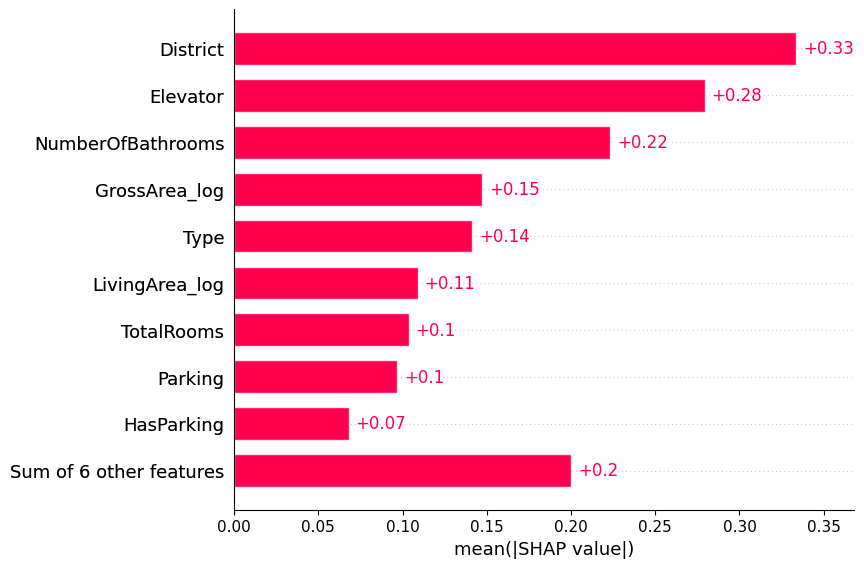

In [3]:
shap.plots.bar(shap_values)

## Beeswarm plot — impact and direction of each feature

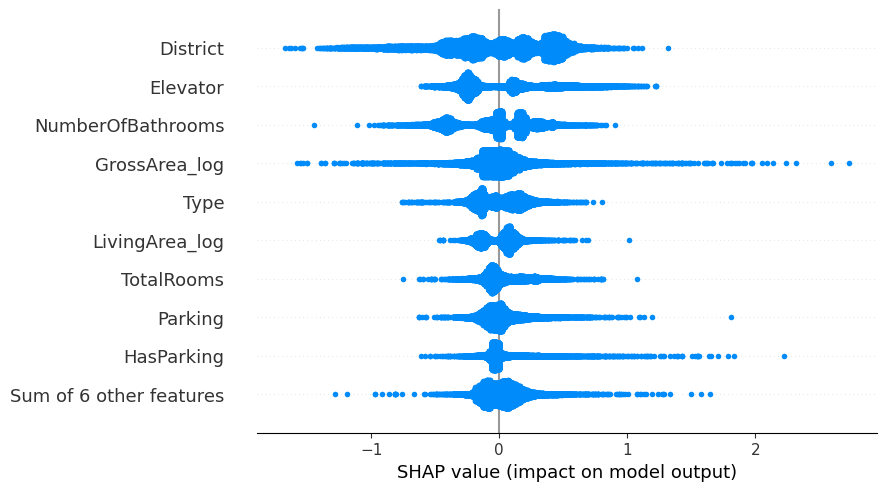

In [4]:
shap.plots.beeswarm(shap_values)

## Waterfall plot — explanation of an individual prediction

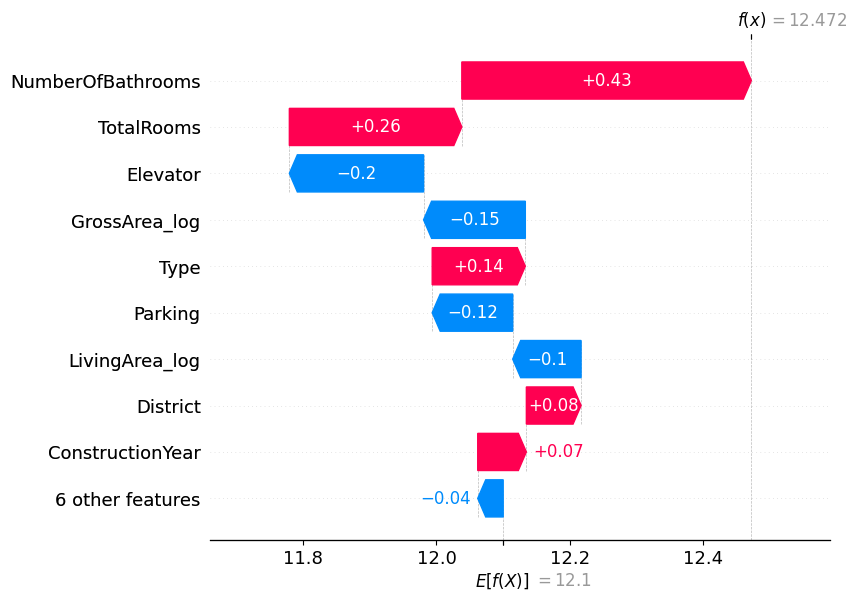

In [5]:
# change the index to explore other observations
idx = 0
shap.plots.waterfall(shap_values[idx])

## Mean absolute SHAP importance per feature

In [6]:
shap_importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

,feature,mean_abs_shap
0,District,0.333849
1,NumberOfBathrooms,0.279429
2,Type,0.223363
3,TotalArea_log,0.147455
4,EnergyCertificate,0.141430
5,TotalRooms,0.109232
6,ConstructionYear,0.103650
7,LivingArea_log,0.096915
8,LotSize_log,0.068284
9,Elevator,0.051823
